<img src="./figs/IOAI-Logo.png" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), Individual Contest](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Pixel/Pixel.ipynb)

# Pixel Efficiency

## 1. Problem Description

You are a student in wildlife biology, working on a groundbreaking research project at the Starr Park Research Center. Your team has deployed thousands of camera traps across remote wilderness areas to monitor endangered species populations. However, the satellite internet connections in these remote locations have extremely limited bandwidth. Your job is to write code that identifies the most critical pixels in each wildlife photograph so that only the essential visual information needs to be transmitted back to headquarters.

<img src="./figs/Pixel Fig 1.png" width="400">

## 2. Dataset

The dataset consists of a training set and a test set. Datasets are loaded using `load_from_disk`, and are in the format of `datasets`. Test set is not visible to the contestants.

In the dataset there are the following fields:

- `image`: the image are RGB full color images in PIL format, the size of each image is (224, 224)
- `name`: the animal species label
- `idx`: unique identifiers used to track the records.

1. **Training Set (`train_dataset` folder)**:
    - The training set is used for training your models/ doing experimentations on and can be accessed and downloaded directly during the competition.
    - There are 700 images in the training set.

2. **Test Set (`test_dataset` folder)**:
    - These follow the same format as the training set but do not contain the `name` field.
    - There are 698 images in test set, which had been separated into 2 testing sets within the ratio of 3:7, i.e. 30% of the data would be used to calculate the Leaderboard A score, another 70% data would be used to calculate the Leaderboard B score.
    - The testing set is used to calculate the Leaderboard A score and the Leaderboard B score and is not directly accessible during the competition. Contestants can access the result on Leaderboard A , but cannot access the result on Leaderboard B. The final score would be counted using Leaderboard B only. The subsets for Leaderboard A and Leaderboard B are completely distinct.
    

## 3. Task
You are given a dataset of animal photographs and a CLIP model that can do a zero-shot classification of animal species. To conserve bandwidth, you need to retain at most **6.25%** of the pixels of each image, while keeping classification accuracy as high as possible.

More specifically, your task is to return **one rectangle mask** for each image, which contain a single rectangular area indicating the area to keep. Each mask is defined by two coordinate tuples: one for the top-left corner and one for the bottom-right corner of the rectangle. Below is a visualization of what the image would look like after applying a rectangular mask using the process from the baseline:

<img src="./figs/Pixel Fig 2.png" width="400">

**Coordinate Convention:**
- Top-left corner coordinates are **inclusive** (the pixel at this position is included in the mask)
- Bottom-right corner coordinates are **exclusive** (the pixel at this position is NOT included in the mask)

For example, if you specify coordinates `((10, 20), (15, 25))`, the mask will cover pixels from row 10 to 14 (inclusive) and column 20 to 24 (inclusive), for a total area of 25 pixels.

As an illustration, if an image size is 3x3 and we wanted to keep only the top-right pixel using coordinates `((0, 2), (1, 3))`, the resulting binary mask would be:

```
[[0, 0, 1],
 [0, 0, 0],
 [0, 0, 0]]
```

Below is a summary of the requirements for your masks:

- Return one rectangle mask defined by coordinate tuples: `((top, left), (bottom, right))`
- Top-left corner coordinates are inclusive, bottom-right corner coordinates are exclusive
- The rectangle mask should cover at most *6.25%* of the original pixels (minimum 93.75% reduction of the original pixels)
- All images are of size (224, 224), so coordinate values should be within the range [0, 224]


Images would be masked using the mask you created, outside the masked rectangle, all pixels outside the masked rectangle will be replaced with RGB(0, 0, 0) (black) values. The masked image will be then passed through the CLIP model during evaluation, and your task is to keep the classification accuracy of the CLIP model on these masked images as high as possible. **An additional `other` class would be added into the classes for classification** to ensure that your masked image retains actual useful information for the researchers back at Starr Park Headquarters. So for example, if your image doesn't contain any animal information, the model will predict the `others` class instead of predicting a random animal and having a chance of getting it correct.

You need to work only with the provided CLIP model and dataset. As a reminder, CLIP generates representations for both text and image, and it can compute a similarity score between them. So if you have ten animal classes, CLIP can look at the provided image and decide which text (class) is closest to the image.

To ensure that your solution would handle the traffic of images for the research center, your code should run in **UNDER 8 MINUTES for the 698 images in the test dataset**. It is recommended that you test your solution on the training set first, which contain 700 images, to understand how much time your solution takes (testing set would take slightly longer due to dataset loading).

## 4. Submission

Contestants need to submit a notebook file named `submission.ipynb`. The file should output a `.jsonl` file titled `submission.jsonl`, which contains all the generated masks for the dataset split. Each mask in the `submission.jsonl` file should be stored as a tuple of two coordinate tuples: `((top, left), (bottom, right))`, where the top-left corner is inclusive and the bottom-right corner is exclusive.

Contestants don't need to separate test sets into Leaderboard A and Leaderboard B, the evaluation machine will read `submission.jsonl` and automatically calculate the scores for Leaderboard A and Leaderboard B based on the prediction results and true labels.

The submission files must strictly follow the above format and naming; otherwise, the system will not be able to read them correctly.

## 5. Score

The evaluation metric will be **classification accuracy**, defined as the proportion of correctly predicted samples over the total number of evaluated samples.

Your score is the zero-shot classification accuracy of CLIP on the masked test images. **If a submitted mask for an image is invalid (wrong shape, more than 6.25% pixels retained, etc.), that image is counted as incorrect. A sample script is provided to compute the training split score.**


## 6. Baseline and Training Set

- Below you can find the baseline solution.
- The dataset is in `training_set` folder.
- The highest score by the Scientific Committee for this task is 0.83 in Leader Board B, this score is used for score unification.
- The baseline score by the Scientific Committee for this task is 0.19 in Leader Board B, this score is used for score unification.

In [ ]:
# Install required packages
!pip install numpy pillow tqdm torch transformers datasets accelerate matplotlib

In [ ]:
!pip install --upgrade transformers

In [ ]:
!git clone --depth 1 https://github.com/IOAI-official/IOAI-2025.git
import os
from pathlib import Path

base_path = Path("/content/IOAI-2025/Individual-Contest/Radar/training_set")

if base_path.exists():
    files = list(base_path.glob("*.mat.pt"))
    print(f"Yes: {len(files)}")
else:
    print("Nooo.")

Cloning into 'IOAI-2025'...
remote: Enumerating objects: 20169, done.
remote: Counting objects: 100% (20169/20169), done.
remote: Compressing objects: 100% (19365/19365), done.
remote: Total 20169 (delta 788), reused 20142 (delta 786), pack-reused 0 (from 0)
Receiving objects: 100% (20169/20169), 2.73 GiB | 15.12 MiB/s, done.
Resolving deltas: 100% (788/788), done.
Updating files: 100% (20080/20080), done.
Yes: 1800


In [ ]:

from datasets import load_dataset
print("Loading dataset...")
# Load dataset directly from HuggingFace without data_dir parameter
# The correct way to load a specific subset/path from a HuggingFace dataset

DATASET_NAME = "IOAI-official/IOAI-2025-Pixel-train"
SPLIT = 'train'
train_dataset = load_dataset(DATASET_NAME, data_dir="data", split=SPLIT)

print(f"Dataset loaded successfully! Total samples: {len(train_dataset)}")

# Print first item to check available fields
print("\nFirst item keys:")
print(train_dataset[0].keys())

# Show basic dataset statistics without converting fields yet
print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(train_dataset)}")

print(f"\nSample item structure:")
sample_item = train_dataset[0]
print(f"  Keys: {list(sample_item.keys())}")
if 'image' in sample_item:
    print(f"  Image type: {type(sample_item['image'])}")
    print(f"  Image size: {sample_item['image'].size}")
else:
    print("  No 'image' field found in dataset")

if 'idx' in sample_item:
    print(f"  Index: {sample_item['idx']}")
else:
    print("  No 'idx' field found in dataset")



Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset loaded successfully! Total samples: 700

First item keys:
dict_keys(['name', 'image', 'idx'])

Dataset loaded successfully!
Total samples: 700

Sample item structure:
  Keys: ['name', 'image', 'idx']
  Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
  Image size: (224, 224)
  Index: 5865e297-23d2-11e8-a6a3-ec086b02610b


In [ ]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)                  # Python built-in random
np.random.seed(seed)               # NumPy
torch.manual_seed(seed)            # PyTorch (CPU)
torch.cuda.manual_seed(seed)       # PyTorch (single GPU)
torch.cuda.manual_seed_all(seed)   # PyTorch (all GPUs)

# Ensures deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Dependencies and Config Variables

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from PIL import Image
from tqdm import tqdm
import glob
import json
import math
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, load_from_disk
from transformers import CLIPModel
from PIL import Image
from tqdm.auto import tqdm


# Dataset configuration
DATASET_PATH = "IOAI-official/IOAI-2025-Pixel-train"
SPLIT = "train"

# Model Configuration
MODEL_PATH = "openai/clip-vit-large-patch14"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BACKGROUND_CLASS = "other"


# Image and Masking Configuration
HEIGHT = 224
WIDTH = 224
RETAIN_RATIO = 0.0625  # Retain 6.25% of pixels
MEAN_COLOR = (0, 0, 0)  # RGB mean values for masked out areas


### Dataset loading

Let's first load the dataset in and see what's in it:


In [ ]:

print("Loading dataset...")
# Load dataset directly from HuggingFace without data_dir parameter
train_dataset = load_dataset(DATASET_PATH, split=SPLIT)

print(f"Dataset loaded successfully! Total samples: {len(train_dataset)}")

# Print first item to check available fields
print("\nFirst item keys:")
print(train_dataset[0].keys())

# Show basic dataset statistics without converting fields yet
print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(train_dataset)}")

print(f"\nSample item structure:")
sample_item = train_dataset[0]
print(f"  Keys: {list(sample_item.keys())}")
print(f"  Image type: {type(sample_item['image'])}")
print(f"  Image size: {sample_item['image'].size}")
print(f"  Index: {sample_item['idx']}")



Loading dataset...
Dataset loaded successfully! Total samples: 700

First item keys:
dict_keys(['name', 'image', 'idx'])

Dataset loaded successfully!
Total samples: 700

Sample item structure:
  Keys: ['name', 'image', 'idx']
  Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
  Image size: (224, 224)
  Index: 5865e297-23d2-11e8-a6a3-ec086b02610b


Visualizing first 10 samples...


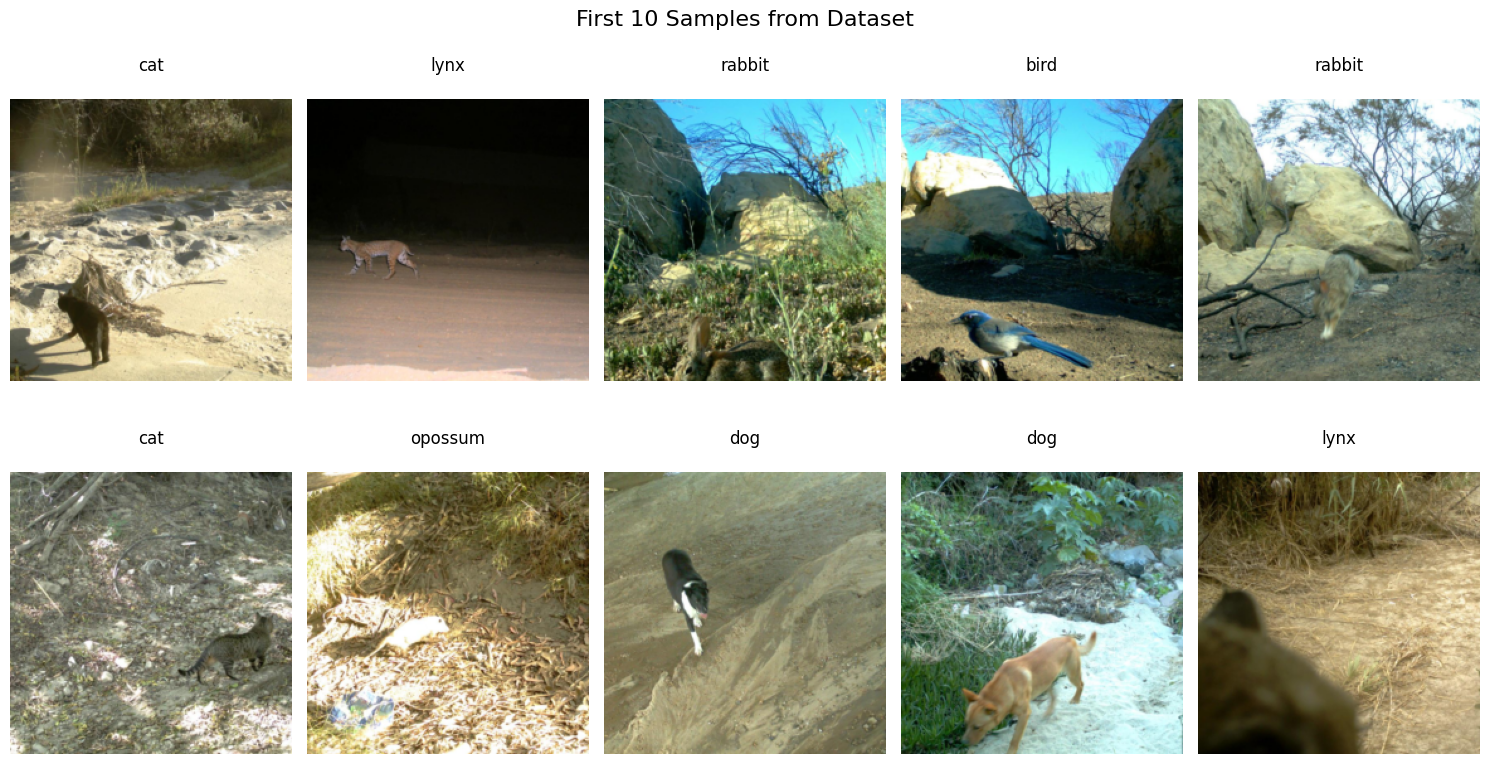

In [ ]:
# Visualize first 10 samples
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

print("Visualizing first 10 samples...")

for i in range(10):
    sample = train_dataset[i]
    image = sample['image']
    label = sample['name']

    axes[i].imshow(image)
    axes[i].set_title(f"{label}\n", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('First 10 Samples from Dataset', fontsize=16, y=1.02)
plt.show()


### Model

Now let's load the model and see some predictions:

In [ ]:
from transformers import CLIPConfig
from transformers import CLIPModel, CLIPProcessor
print(f"Loading CLIP model and processor: {MODEL_PATH}...")
config = CLIPConfig.from_pretrained(MODEL_PATH)
config.vision_config.output_attentions = True

model = CLIPModel.from_pretrained(MODEL_PATH, config=config, attn_implementation="eager").to(DEVICE)
processor = CLIPProcessor.from_pretrained(MODEL_PATH)
print("Model and processor loaded successfully.")

Loading CLIP model and processor: openai/clip-vit-large-patch14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model and processor loaded successfully.


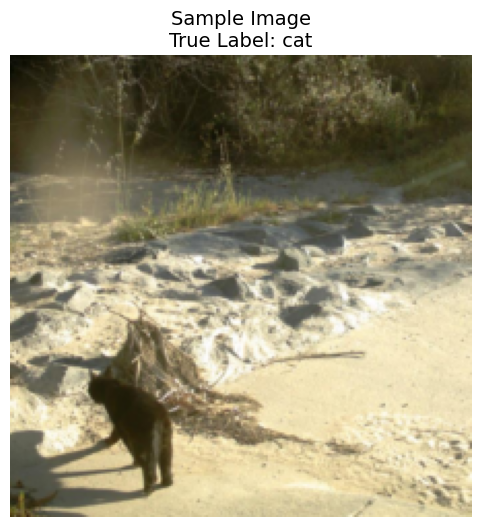

labels: ['bird', 'cat', 'deer', 'dog', 'lynx', 'opossum', 'rabbit', 'skunk', 'squirrel', 'other']
torch.Size([1, 3, 224, 224])
Predicted label: cat


In [ ]:
image = train_dataset[0]['image']
# Visualize the image with its true label
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"Sample Image\nTrue Label: {train_dataset[0]['name']}", fontsize=14)
plt.axis('off')
plt.show()


labels = sorted(list(set(train_dataset['name']))) + [BACKGROUND_CLASS]
print(f"labels: {labels}")

text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(DEVICE)
image_processed = processor(images=image, return_tensors="pt").to(DEVICE)

pixel_values = image_processed['pixel_values']
print(pixel_values.shape)

outputs_full = model(pixel_values=pixel_values, **text_inputs)
logits_full = outputs_full.logits_per_image  # Shape: (1, num_styles)
predicted_index_full = logits_full.argmax(dim=-1).item()

print(f"Predicted label: {labels[predicted_index_full]}")


### Baseline: A trivial masking method

We will now be implementing a trivial masking solution, one that randomly masks out 90% of the pixels.

In [ ]:
R = torch.eye(197)
print(R)
A = torch.rand(197, 197)
print(A)
print()
print(A@R)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
tensor([[0.5523, 0.5082, 0.4831,  ..., 0.3373, 0.6638, 0.9271],
        [0.6632, 0.4905, 0.5455,  ..., 0.3474, 0.5883, 0.9778],
        [0.4596, 0.7777, 0.8556,  ..., 0.1338, 0.7428, 0.1426],
        ...,
        [0.9478, 0.3146, 0.6465,  ..., 0.9089, 0.7621, 0.6984],
        [0.4024, 0.9187, 0.0673,  ..., 0.8847, 0.4489, 0.3490],
        [0.7868, 0.4896, 0.0127,  ..., 0.9262, 0.4182, 0.8350]])

tensor([[0.5523, 0.5082, 0.4831,  ..., 0.3373, 0.6638, 0.9271],
        [0.6632, 0.4905, 0.5455,  ..., 0.3474, 0.5883, 0.9778],
        [0.4596, 0.7777, 0.8556,  ..., 0.1338, 0.7428, 0.1426],
        ...,
        [0.9478, 0.3146, 0.6465,  ..., 0.9089, 0.7621, 0.6984],
        [0.4024, 0.9187, 0.0673,  ..., 0.8847, 0.4489, 0.3490],
        [0.786

In [ ]:
def generate_center_crop_coordinates(image):
    """
    Generate coordinates for a center crop mask.

    Returns:
        tuple: ((top, left), (bottom, right)) coordinates for the crop
    """
    H, W = image.size
    total_px = H * W
    k = int(total_px * RETAIN_RATIO)

    # Calculate side length of the square crop
    side_length = int(np.sqrt(k))

    # Calculate center coordinates
    center_h, center_w = H // 2, W // 2

    # Calculate crop boundaries
    half_side = side_length // 2
    top = max(0, center_h - half_side)
    left = max(0, center_w - half_side)
    bottom = min(H, top + side_length)
    right = min(W, left + side_length)

    return ((top, left), (bottom, right))

def generate_mask_from_coordinates(image, coordinates):
    """
    Generate a binary mask from crop coordinates.

    Parameters:
        image: PIL Image
        coordinates: tuple of ((top, left), (bottom, right))

    Returns:
        numpy array: Binary mask with 1s in the crop area
    """
    H, W = image.size
    mask = np.zeros((H, W), dtype=np.int8)

    (top, left), (bottom, right) = coordinates
    mask[top:bottom, left:right] = 1

    return mask

In [ ]:
def apply_mask_with_mean(image, mask, mean_rgb=MEAN_COLOR):
    """
    Apply arbitrary binary mask to image, replacing masked areas with mean values

    Parameters:
    - image: PIL Image (224x224)
    - mask: Binary numpy array or PIL Image (224x224) where 0 is the area to drop and 1 is the area to keep
    - mean_rgb: RGB mean values to use (default: from config)

    Returns: Modified PIL Image
    """
    # Convert images to numpy arrays
    img_array = np.array(image).copy()

    # Ensure mask is numpy array
    if isinstance(mask, Image.Image):
        mask_array = np.array(mask.convert('L')) > 127  # Convert to binary
    else:
        mask_array = mask > 0

    # Reshape mask for broadcasting with RGB
    mask_3d = np.stack([mask_array] * 3, axis=2)

    # Convert mean values to 0-255 range
    mean_values = np.array([int(m * 255) for m in mean_rgb])
    # Apply mask - replace areas where mask is 0 (drop) with mean values, keep areas where mask is 1
    img_array = np.where(mask_3d, img_array, mean_values.reshape(1, 1, 3))

    return Image.fromarray(img_array.astype(np.uint8))

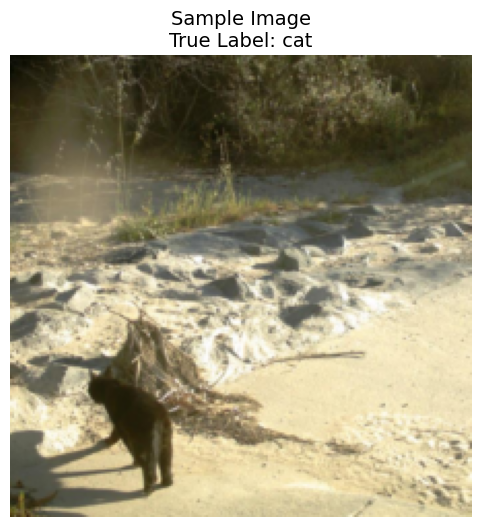

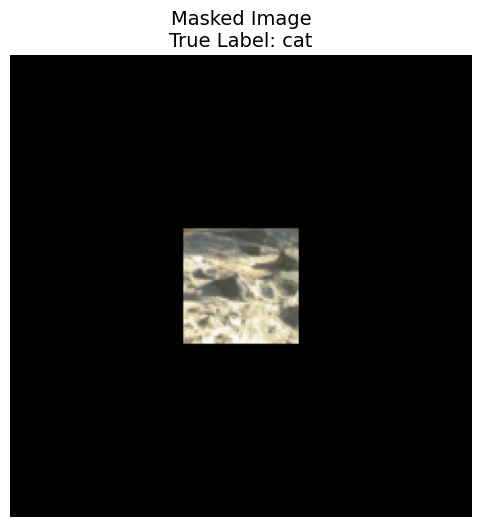

Predicted label: other


In [ ]:
image = train_dataset[0]['image']
# Visualize the image with its true label
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"Sample Image\nTrue Label: {train_dataset[0]['name']}", fontsize=14)
plt.axis('off')
plt.show()


labels = sorted(list(set(train_dataset['name']))) + [BACKGROUND_CLASS]
text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(DEVICE)

mask = generate_mask_from_coordinates(image, generate_center_crop_coordinates(image))
image_masked = apply_mask_with_mean(image, mask)

plt.figure(figsize=(8, 6))
plt.imshow(image_masked)
plt.title(f"Masked Image\nTrue Label: {train_dataset[0]['name']}", fontsize=14)
plt.axis('off')
plt.show()

image_processed = processor(images=image_masked, return_tensors="pt").to(DEVICE)
pixel_values = image_processed['pixel_values']
outputs_full = model(pixel_values=pixel_values, **text_inputs)
logits_full = outputs_full.logits_per_image  # Shape: (1, num_styles)
predicted_index_full = logits_full.argmax(dim=-1).item()

print(f"Predicted label: {labels[predicted_index_full]}")

###My Solution

In [ ]:
!pip install torchvision
import torchvision
from torchvision import transforms
import PIL
from PIL import Image

In [ ]:
# Run this once after loading the model
model.vision_model.config._attn_implementation = "eager"

# Also patch each attention layer's config reference
for layer in model.vision_model.encoder.layers:
    layer.self_attn.config._attn_implementation = "eager"

print("Set to eager. Verifying...")
print(model.vision_model.encoder.layers[0].self_attn.config._attn_implementation)

Set to eager. Verifying...
eager


In [ ]:
def generate_mask_from_coordinates(image, coordinates):
    """
    Generate a binary mask from crop coordinates.

    Parameters:
        image: PIL Image
        coordinates: tuple of ((top, left), (bottom, right))

    Returns:
        numpy array: Binary mask with 1s in the crop area
    """
    H, W = image.size
    mask = np.zeros((H, W), dtype=np.int8)

    (top, left), (bottom, right) = coordinates
    mask[top:bottom, left:right] = 1

    return mask

def apply_mask_with_mean(image, mask, mean_rgb=MEAN_COLOR):
    """
    Apply arbitrary binary mask to image, replacing masked areas with mean values

    Parameters:
    - image: PIL Image (224x224)
    - mask: Binary numpy array or PIL Image (224x224) where 0 is the area to drop and 1 is the area to keep
    - mean_rgb: RGB mean values to use (default: from config)

    Returns: Modified PIL Image
    """
    # Convert images to numpy arrays
    img_array = np.array(image).copy()

    # Ensure mask is numpy array
    if isinstance(mask, Image.Image):
        mask_array = np.array(mask.convert('L')) > 127  # Convert to binary
    else:
        mask_array = mask > 0

    # Reshape mask for broadcasting with RGB
    mask_3d = np.stack([mask_array] * 3, axis=2)

    # Convert mean values to 0-255 range
    mean_values = np.array([int(m * 255) for m in mean_rgb])
    # Apply mask - replace areas where mask is 0 (drop) with mean values, keep areas where mask is 1
    img_array = np.where(mask_3d, img_array, mean_values.reshape(1, 1, 3))

    return Image.fromarray(img_array.astype(np.uint8))



In [ ]:
def get_attention_map(model, processor, image):
  inputs = processor(images=image, return_tensors='pt').to(DEVICE)
  with torch.no_grad():
    # outputs = model.vision_model(inputs['pixel_values'], output_attentions=True)
    outputs, attentions = model(inputs['pixel_values'])

  # attentions = outputs.attentions  #(1, num_heads, 256, 256)
  if attentions is None:
        raise ValueError("Still None — eager patch didn't apply.")


  R = torch.eye(attentions[0].size(-1)).to(DEVICE)
  I = torch.eye(attentions[0].size(-1)).to(DEVICE)

  for A in attentions:
    A = A[0]
    head_weights = A.mean(dim=(1, 2))
    head_weights = head_weights / head_weights.sum()
    A = (A * head_weights[:, None, None]).sum(dim=0)
    # A = A.mean(dim=1)[0]
    A = A + I
    A = A / A.sum(dim=-1, keepdim=True)
    R = A@R

  mask = R[0, 1:]
  mask = mask.reshape(16, 16)
  # mask = torch.nn.functional.interpolate(
  #     mask.unsqueeze(0).unsqueeze(0),
  #     size=(224, 224),
  #     mode='bilinear',
  #     align_corners=False
  # ).squeeze()
  return mask.squeeze()


#i dont use this
def get_attention_clusterized_map(model, processor, image):
  from sklearn.cluster import SpectralClustering
  from sklearn.preprocessing import normalize

  inputs = processor(images=image, return_tensors='pt').to(DEVICE)
  with torch.no_grad():
    # outputs = model.vision_model(inputs['pixel_values'], output_attentions=True)
    outputs, attentions = model(inputs['pixel_values'])

  # attentions = outputs.attentions  #(1, num_heads, 256, 256)
  if attentions is None:
        raise ValueError("Still None — eager patch didn't apply.")


  R = torch.eye(attentions[0].size(-1)).to(DEVICE)
  I = torch.eye(attentions[0].size(-1)).to(DEVICE)

  for A in attentions:
    A = A[0]
    head_weights = A.mean(dim=(1, 2))
    head_weights = head_weights / head_weights.sum()
    A = (A * head_weights[:, None, None]).sum(dim=0)
    # A = A.mean(dim=1)[0]
    A = A + I
    A = A / A.sum(dim=-1, keepdim=True)
    R = A@R

  X = R[1:, 1:]
  cls = R[0, 1:]
  X = torch.cat([X, cls[:, None]], axis=1)
  X = normalize(X.cpu().numpy())
  labels = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', assign_labels='kmeans').fit_predict(X)
  mask = labels.reshape(16, 16)

  # mask = mask.reshape(16, 16)
  # mask = torch.nn.functional.interpolate(
  #     mask.unsqueeze(0).unsqueeze(0),
  #     size=(224, 224),
  #     mode='bilinear',
  #     align_corners=False
  # ).squeeze()
  return mask.squeeze()

In [ ]:
def generate_coordinates(model, processor, image, text_inputs, labels):
  # map = get_attention_map(model, processor, image).cpu().detach().numpy()
  map = get_attention_map(model, processor, image).cpu().detach().numpy()
  flat_idx = np.argmax(map)
  vr, vc = int(flat_idx//16), int(flat_idx%16)

  with torch.no_grad():
    inputs = processor(images=image, return_tensors='pt').to(DEVICE)
    # outputs = model(pixel_values=inputs['pixel_values'], **text_inputs)
    outputs, _ = model(inputs['pixel_values'])
    # target_idx = outputs.logits_per_image.argmax(dim=-1).item()
    target_idx = outputs.argmax(dim=-1).item()

  best_confidence=-1
  best_coordinates=((0, 0), (56, 56))
  patch_size=14

  for tr in range(max(0, vr-3), min(vr+1, 13)):
    for tc in range(max(0, vc-3), min(vc+1, 13)):
      top, left = tr*patch_size, tc*patch_size
      bottom, right = top+56, left+56
      current_coordinates = ((top, left), (bottom, right))

      mask = generate_mask_from_coordinates(image, current_coordinates)
      masked_img = apply_mask_with_mean(image, mask)

      test_inputs = processor(images=masked_img, return_tensors='pt').to(DEVICE)
      with torch.no_grad():
        # test_outputs = model(pixel_values=test_inputs['pixel_values'], **text_inputs)
        test_outputs, _ = model(test_inputs['pixel_values'])
        # pred_logits = test_outputs.logits_per_image.softmax(dim=-1)
        pred_logits = test_outputs.softmax(dim=-1)

      confidence = pred_logits[0, target_idx].item()
      if confidence > best_confidence:
        best_confidence = confidence
        best_coordinates = current_coordinates

  return best_coordinates

### With custom dataset and new training loop

In [ ]:
from torch.utils.data import Dataset, DataLoader
class CustomDataset(Dataset):
  def __init__(self, dataset, processor, device):
    super().__init__()
    self.labels =  sorted(list(set(dataset['name']))) + [BACKGROUND_CLASS]
    self.text_inputs = processor(text=labels, return_tensors='pt', padding=True).to(device)

    self.dataset = dataset
    self.processor = processor
    self.device = device

    self.labels2idx = {label: i for i, label in enumerate(self.labels)}

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, item):
    sample = self.dataset[item]
    name = sample["name"]
    image = sample["image"]
    idx = sample['idx']
    label = self.labels2idx[name]
    image_processed = self.processor(images=image, return_tensors='pt').to(self.device)
    pixel_values = image_processed['pixel_values']

    return {'pixel_values': pixel_values,
            'labels': label,
            'images': image
            }

def custom_colatte(batch):
  pixel_values = torch.stack([item['pixel_values'].squeeze(0) for item in batch])
  labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
  images = [item['images'] for item in batch]

  return {'pixel_values': pixel_values,
          'labels': labels,
          "images": images}

train_custom = CustomDataset(train_dataset, processor, DEVICE)
train_dataloader = DataLoader(train_custom, batch_size=16, shuffle=True, collate_fn=custom_colatte)

In [ ]:
import torch.nn as nn

labels = sorted(list(set(train_dataset['name']))) + [BACKGROUND_CLASS]
text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(DEVICE)

class CLIPModelV1(nn.Module):
  def __init__(self, model):
    super().__init__()

    for param in model.parameters():
      param.requires_grad = False
    model.requires_grad = False
    model.requires_grad_(False)
    for layer in model.vision_model.encoder.layers:
      layer.requires_grad = False
      layer.requires_grad_(False)

    for block in model.vision_model.encoder.layers[-2:]:
      for param in block.parameters():
        param.requires_grad = True

    self.vision_model = model.vision_model
    self.layer = nn.Sequential(
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Linear(256, len(labels))
    ).to(DEVICE)
    # self.layer = nn.Linear(1024, len(labels)).to(DEVICE)

  def forward(self, pixel_values):
    outputs = self.vision_model(pixel_values, output_attentions=True)
    attn_w = outputs.attentions
    out = self.layer(outputs.pooler_output)
    return out, attn_w

my_model = CLIPModelV1(model)
optimizer = torch.optim.AdamW([{"params": my_model.layer.parameters(), "lr": 0.001},
                               {"params": filter(lambda p: p.requires_grad, my_model.vision_model.parameters()), "lr": 0.00001}])
loss_fn = nn.CrossEntropyLoss()

from tqdm.auto import tqdm
epochs = 5
my_model.train()
for epoch in tqdm(range(epochs)):
  avg_loss = 0
  for batch in train_dataloader:
    pixel_values = batch['pixel_values'].to(DEVICE)
    images = batch['images']
    labels = batch['labels'].to(DEVICE)
    optimizer.zero_grad()

    #image masking
    with torch.no_grad():
      masked_images = []
      for img in images:
        mask = generate_mask_from_coordinates(img, generate_coordinates(my_model, processor, img, text_inputs, labels))
        masked_img = apply_mask_with_mean(img, mask)
        masked_images.append(masked_img)
    pixel_values = processor(images=masked_images, return_tensors='pt').to(DEVICE)['pixel_values']
    logits, _ = my_model(pixel_values)
    loss = loss_fn(logits, labels)
    avg_loss+=loss.item()
    loss.backward()
    optimizer.step()

  avg_loss /= len(train_dataset)
  print(f"Epoch: {epoch} | Loss: {avg_loss}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.09354059977190834
Epoch: 1 | Loss: 0.05809866151639394
Epoch: 2 | Loss: 0.03860371287379946
Epoch: 3 | Loss: 0.026385971988950457
Epoch: 4 | Loss: 0.017014826121074814


### old training loop

In [ ]:
import torch.nn as nn

labels = sorted(list(set(train_dataset['name']))) + [BACKGROUND_CLASS]
text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(DEVICE)

class CLIPModelV1(nn.Module):
  def __init__(self, model):
    super().__init__()

    for param in model.parameters():
      param.requires_grad = False
    model.requires_grad = False
    model.requires_grad_(False)
    for layer in model.vision_model.encoder.layers:
      layer.requires_grad = False
      layer.requires_grad_(False)

    for block in model.vision_model.encoder.layers[-2:]:
      for param in block.parameters():
        param.requires_grad = True

    self.vision_model = model.vision_model
    self.layer = nn.Sequential(
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Linear(256, len(labels))
    ).to(DEVICE)
    # self.layer = nn.Linear(1024, len(labels)).to(DEVICE)

  def forward(self, pixel_values):
    outputs = self.vision_model(pixel_values, output_attentions=True)
    attn_w = outputs.attentions
    out = self.layer(outputs.pooler_output)
    return out, attn_w

my_model = CLIPModelV1(model)
optimizer = torch.optim.AdamW([{"params": my_model.layer.parameters(), "lr": 0.001},
                               {"params": filter(lambda p: p.requires_grad, my_model.vision_model.parameters()), "lr": 0.00001}])
loss_fn = nn.CrossEntropyLoss()

from tqdm.auto import tqdm
epochs = 5
my_model.train()
for epoch in tqdm(range(epochs)):
  avg_loss = 0
  for batch in train_dataset:
    image = batch['image']
    name = batch['name']

    true_label_idx = labels.index(name)
    target = torch.tensor([true_label_idx], dtype=torch.long).to(DEVICE)

    optimizer.zero_grad()

    # image_processed = processor(images=image, return_tensors="pt").to(DEVICE)

    my_model.eval()
    with torch.inference_mode():
      mask = generate_mask_from_coordinates(image, generate_coordinates(my_model, processor, image, text_inputs, labels))
      image_masked = apply_mask_with_mean(image, mask)
    masked_image_processed = processor(images=image_masked, return_tensors='pt').to(DEVICE)

    my_model.train()
    pixel_values = masked_image_processed['pixel_values']
    logits_full, attentions = my_model(pixel_values)
    # predicted_index_full = logits_full.argmax(dim=-1).item()


    loss = loss_fn(logits_full, target)
    avg_loss += loss.item()


    loss.backward()
    optimizer.step()

  avg_loss /= len(train_dataset)
  print(f"Epoch: {epoch} | Loss: {avg_loss}")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Loss: 1.4406037698959386
Epoch: 1 | Loss: 0.9801213936466638
Epoch: 2 | Loss: 0.6844532103325327
Epoch: 3 | Loss: 0.5291546764702857
Epoch: 4 | Loss: 0.5236861674053196


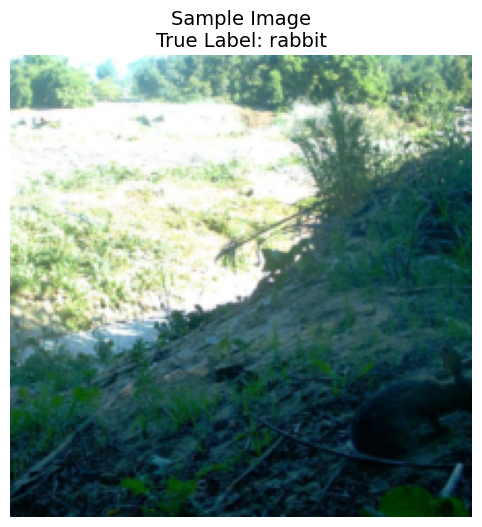

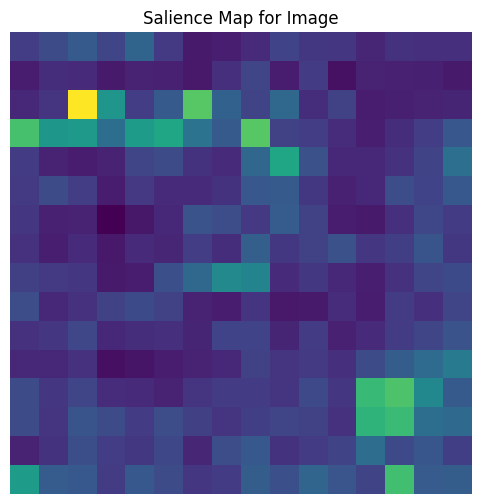

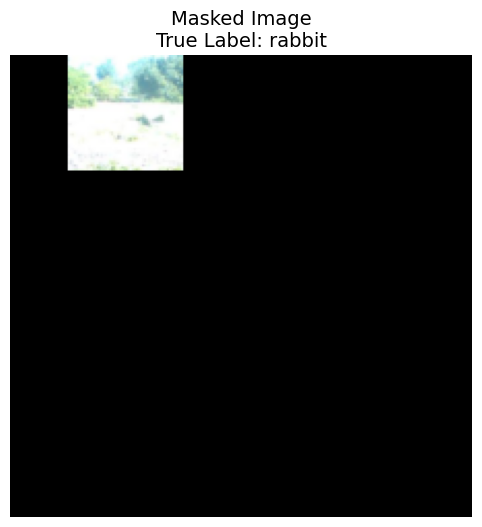

Predicted label: rabbit


In [ ]:
my_model.eval()
image = train_dataset[680]['image']
# Visualize the image with its true label
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"Sample Image\nTrue Label: {train_dataset[680]['name']}", fontsize=14)
plt.axis('off')
plt.show()


labels = sorted(list(set(train_dataset['name']))) + [BACKGROUND_CLASS]
text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(DEVICE)

salience = get_attention_map(model=my_model, processor=processor, image=image)
plt.figure(figsize=(8, 6))
plt.imshow(salience.cpu().detach().numpy())
plt.title("Salience Map for Image")
plt.axis('off')
plt.show()

mask = generate_mask_from_coordinates(image, generate_coordinates(my_model, processor, image, text_inputs, labels))
image_masked = apply_mask_with_mean(image, mask)

plt.figure(figsize=(8, 6))
plt.imshow(image_masked)
plt.title(f"Masked Image\nTrue Label: {train_dataset[680]['name']}", fontsize=14)
plt.axis('off')
plt.show()

image_processed = processor(images=image_masked, return_tensors="pt").to(DEVICE)
pixel_values = image_processed['pixel_values']
# outputs_full = model(pixel_values=pixel_values, **text_inputs)
# logits_full = outputs_full.logits_per_image  # Shape: (1, num_styles)
# predicted_index_full = logits_full.argmax(dim=-1).item()
outputs, _ = my_model(pixel_values)
predicted_index_full = outputs.argmax(dim=-1).item()

print(f"Predicted label: {labels[predicted_index_full]}")

### Exporting the masks


In [ ]:
class CustomTestDataset(Dataset):
  def __init__(self, dataset, processor, device):
    super().__init__()
    self.dataset = dataset
    self.processor = processor
    self.device = device

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, item):
    sample = self.dataset[item]
    image = sample["image"]
    idx = sample["idx"]

    image_processed = self.processor(images=image, return_tensors='pt').to(self.device)
    pixel_values = image_processed['pixel_values']

    return {"pixel_values": pixel_values,
            "images": images}

def custom_test_collate(batch):
  pixel_values = torch.stack([item["pixel_values"].squeeze(0) for item in batch])
  images = [item["images"] for item in batch]

  return {'pixel_values': pixel_values,
          'images': images}

In [ ]:
test_dataset = load_dataset("IOAI-official/IOAI-2025-Pixel-test", split="test")
# test_custom = CustomDataset(test_dataset, processor, DEVICE)
# test_dataloader = DataLoader(test_custom, batch_size=16, shuffle=False, collate_fn=custom_test_collate)

In [ ]:
## Exporting results and validating on full dataset
RETAIN_RATIO = 0.0625

masks = {}
for item in tqdm(test_dataset):
    image = item['image']

    ## you should replace mask generation with your function
    coordinates = generate_coordinates(my_model, processor, image, text_inputs, labels)

    # don't need to change below, it's just saving to file
    idx = item['idx']
    # For validation, we still need to generate the full mask
    mask = generate_mask_from_coordinates(image, coordinates)
    assert mask.shape == (224, 224), "Mask should be 224x224"
    assert mask.sum() <= RETAIN_RATIO * 224 * 224, "You should leave only 6.25% of pixels"

    # Save only the coordinates (topleft, bottomright) instead of the full mask
    masks[idx] = coordinates

# Save as JSONL (one JSON object per line) - much safer than pickle
with open('submission.jsonl', 'w') as f:
    for idx, coordinates in masks.items():
        json.dump({"idx": idx, "coordinates": coordinates}, f)
        f.write('\n')

print("Masks saved to submission.jsonl")

  0%|          | 0/698 [00:00<?, ?it/s]

Masks saved to submission.jsonl


### Validation

In [ ]:
# Validation code for generated masks

def check_validity(coordinates):
    """
    Check if coordinates are valid according to the requirements.
    Returns True if valid, False otherwise.
    """
    try:
        # Check if coordinates is a tuple of two tuples
        if not isinstance(coordinates, tuple) or len(coordinates) != 2:
            print(f"Coordinates is not a tuple of two tuples")
            return False

        (top, left), (bottom, right) = coordinates

        # Check if all coordinates are integers
        if not all(isinstance(coord, (int, np.integer)) for coord in [top, left, bottom, right]):
            print(f"Coordinates are not integers")
            return False

        # Check if coordinates are within image bounds
        # For slicing mask[top:bottom, left:right], valid ranges are:
        # top, left: [0, 223] (inclusive)
        # bottom, right: [1, 224] (inclusive) since we need top < bottom and left < right
        if not (0 <= top < 224 and 0 <= left < 224 and 1 <= bottom <= 224 and 1 <= right <= 224):
            print(f"Coordinates are not within image bounds")
            return False

        # Check if top-left is actually top-left of bottom-right (proper ordering)
        if not (top < bottom and left < right):
            print(f"Top-left is not actually top-left of bottom-right")
            return False

        # Check that the crop area doesn't exceed RETAIN_RATIO
        crop_area = (bottom - top) * (right - left)
        max_area = RETAIN_RATIO * 224 * 224
        if crop_area > max_area:
            print(f"Crop area {crop_area} exceeds max area {max_area}")
            return False

        return True
    except Exception:
        return False




def validate_masks(masks):
    """Simple validation of generated masks on the dataset"""
    correct = 0
    total = 0

    labels = sorted(list(set(train_dataset['name']))) + ['other']

    text_inputs = processor(text=labels, return_tensors="pt", padding=True).to(DEVICE)

    with torch.no_grad():
        for item in tqdm(test_dataset, desc="Validating masks"):
            idx = item['idx']
            if idx not in masks:
                continue

            if not check_validity(masks[idx]):
                continue

            mask_coordinates = masks[idx]
            image = item['image']
            # true_label = item['name']
            test_image_processed = processor(images=image, return_tensors="pt").to(DEVICE)
            pixel_values = test_image_processed['pixel_values']
            # outputs_full = model(pixel_values=pixel_values, **text_inputs)
            # logits_full = outputs_full.logits_per_image  # Shape: (1, num_styles)
            # predicted_index_full = logits_full.argmax(dim=-1).item()
            # true_label = labels[predicted_index_full]
            output, _ = my_model(pixel_values)
            predicted_index_full = output.argmax(dim=-1).item()
            true_label = labels[predicted_index_full]

            # Apply mask to image
            if image.mode != "RGB":
                image = image.convert("RGB")

            mask = generate_mask_from_coordinates(image, mask_coordinates)

            # Apply mask with mean color replacement
            img_array = np.array(image).copy()
            mask_array = mask > 0
            mask_3d = np.stack([mask_array] * 3, axis=2)
            mean_values = np.array([0, 0, 0])  # Black mean color
            img_array = np.where(mask_3d, img_array, mean_values.reshape(1, 1, 3))
            masked_image = Image.fromarray(img_array.astype(np.uint8))

            # Get prediction on masked image
            image_processed = processor(images=masked_image, return_tensors="pt").to(DEVICE)
            pixel_values = image_processed['pixel_values']
            # outputs = model(pixel_values=pixel_values, **text_inputs)
            # logits = outputs.logits_per_image
            # predicted_idx = logits.argmax(dim=-1).item()
            # predicted_label = labels[predicted_idx]
            outputs, _ = my_model(pixel_values)
            predicted_idx = outputs.argmax(dim=-1).item()
            predicted_label = labels[predicted_idx]

            # Check if prediction is correct
            if predicted_label == true_label:
                correct += 1
            total += 1

    accuracy = correct / total if total > 0 else 0
    print(f"Validation Results:")
    print(f"Total samples: {total}")
    print(f"Correct predictions: {correct}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    return accuracy

# Run validation
accuracy = validate_masks(masks)


NameError: name 'masks' is not defined